In [2]:
# Import libraries

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns


# Machine Learning

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso


# Scaling

from sklearn.preprocessing import StandardScaler


# Evaluation Metrics

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
# Read dataset

df = pd.read_csv(r"C:\Users\suman\Downloads\ToyotaCorolla - MLR.csv")


# Display first 5 rows

df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.shape

(1436, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1436 non-null   int64
 1   Age_08_04  1436 non-null   int64
 2   KM         1436 non-null   int64
 3   Fuel_Type  1436 non-null   str  
 4   HP         1436 non-null   int64
 5   Automatic  1436 non-null   int64
 6   cc         1436 non-null   int64
 7   Doors      1436 non-null   int64
 8   Cylinders  1436 non-null   int64
 9   Gears      1436 non-null   int64
 10  Weight     1436 non-null   int64
dtypes: int64(10), str(1)
memory usage: 131.9 KB


In [6]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [7]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

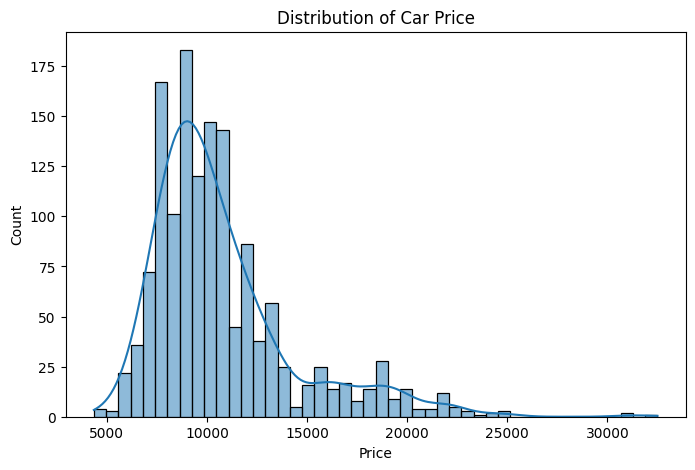

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Price'],
    kde=True
)

plt.title("Distribution of Car Price")

plt.show()

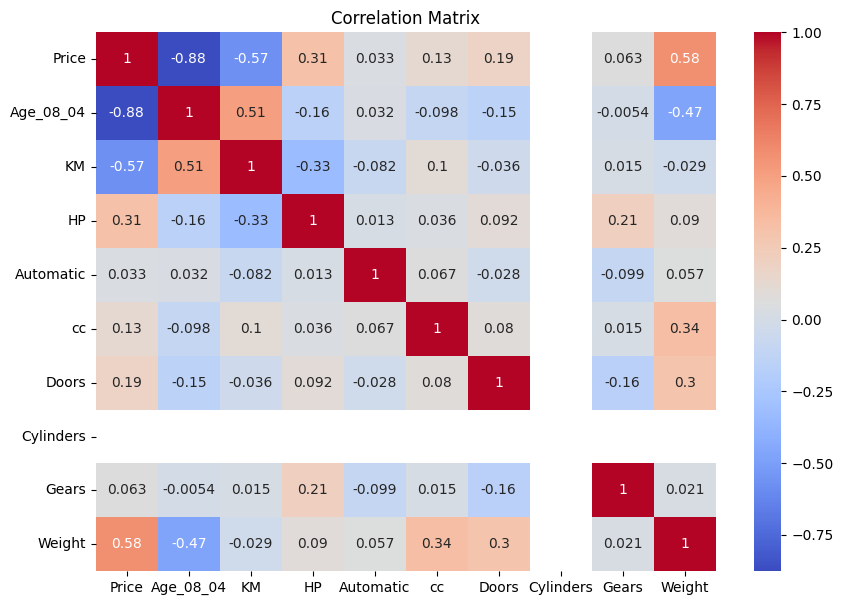

In [9]:
plt.figure(figsize=(10,7))


corr = df.corr(numeric_only=True)


sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)


plt.title("Correlation Matrix")

plt.show()

In [10]:
# Check column names

df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='str')

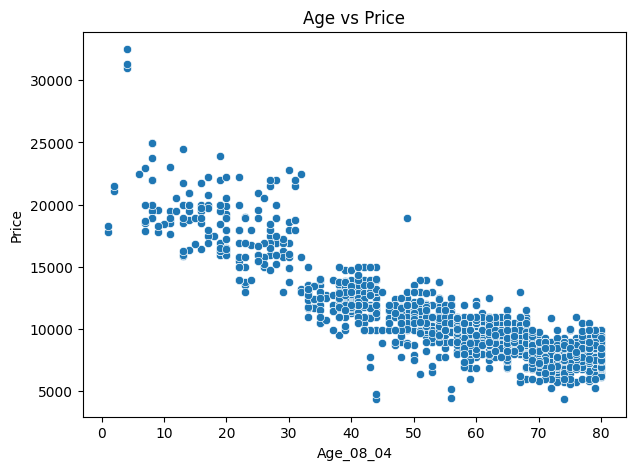

In [11]:
plt.figure(figsize=(7,5))


sns.scatterplot(
    data=df,
    x="Age_08_04",
    y="Price"
)


plt.title("Age vs Price")

plt.show()

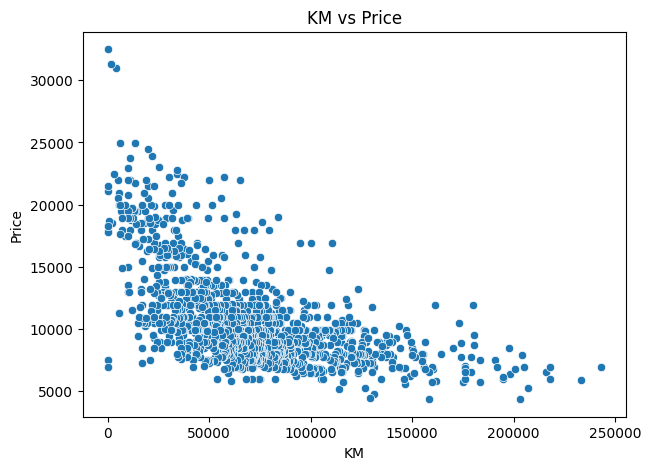

In [12]:
plt.figure(figsize=(7,5))


sns.scatterplot(
    data=df,
    x="KM",
    y="Price"
)


plt.title("KM vs Price")

plt.show()

In [13]:
df = pd.get_dummies(
    df,
    columns=['Fuel_Type'],
    drop_first=True
)


df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [14]:
# Independent variables

X = df.drop(
    "Price",
    axis=1
)


# Dependent variable

y = df["Price"]


print(X.shape)

print(y.shape)


(1436, 11)
(1436,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)


print(X_train.shape)

print(X_test.shape)

(1148, 11)
(288, 11)


In [16]:
def evaluate_model(actual, predicted):

    print("MAE:",
          mean_absolute_error(actual,predicted))


    print("MSE:",
          mean_squared_error(actual,predicted))


    print("RMSE:",
          np.sqrt(mean_squared_error(actual,predicted)))


    print("R2 Score:",
          r2_score(actual,predicted))

In [17]:
# Create model

model1 = LinearRegression()


# Train

model1.fit(
    X_train,
    y_train
)


# Prediction

prediction1 = model1.predict(X_test)


evaluate_model(
    y_test,
    prediction1
)

MAE: 990.8872739193923
MSE: 2203043.8231437006
RMSE: 1484.2654153296508
R2 Score: 0.8348888040611084


In [18]:
coeff = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":model1.coef_

})


coeff

,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,1.250555e-12
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


In [19]:
X2 = df[
[
"Age_08_04",
"KM",
"HP",
"Weight",
"cc"
]
]


y2 = df["Price"]



X_train2,X_test2,y_train2,y_test2 = train_test_split(

    X2,
    y2,
    test_size=0.2,
    random_state=42

)


model2 = LinearRegression()


model2.fit(
    X_train2,
    y_train2
)


prediction2 = model2.predict(X_test2)



evaluate_model(
    y_test2,
    prediction2
)

MAE: 998.544880417576
MSE: 1995964.8372853622
RMSE: 1412.786196593583
R2 Score: 0.8504087218447197


In [20]:
scaler = StandardScaler()


X_scaled = scaler.fit_transform(X)



X_train3,X_test3,y_train3,y_test3 = train_test_split(

    X_scaled,
    y,
    test_size=0.2,
    random_state=42

)

In [21]:
model3 = LinearRegression()


model3.fit(
    X_train3,
    y_train3
)


prediction3 = model3.predict(X_test3)



evaluate_model(
    y_test3,
    prediction3
)

MAE: 990.8872739193968
MSE: 2203043.823143705
RMSE: 1484.2654153296521
R2 Score: 0.834888804061108


In [22]:
ridge = Ridge(
    alpha=1
)


ridge.fit(
    X_train,
    y_train
)


ridge_prediction = ridge.predict(X_test)


evaluate_model(
    y_test,
    ridge_prediction
)

MAE: 990.733834202601
MSE: 2199746.3702333346
RMSE: 1483.1541963778866
R2 Score: 0.835135937771234


In [23]:
lasso = Lasso(
    alpha=1
)


lasso.fit(
    X_train,
    y_train
)


lasso_prediction = lasso.predict(X_test)


evaluate_model(
    y_test,
    lasso_prediction
)

MAE: 990.9546616159033
MSE: 2195387.2460865397
RMSE: 1481.6839224634043
R2 Score: 0.8354626403967389


In [24]:
results = pd.DataFrame({

"Model":[
"Linear Regression",
"Ridge",
"Lasso"
],

"R2 Score":[

r2_score(y_test,prediction1),

r2_score(y_test,ridge_prediction),

r2_score(y_test,lasso_prediction)

]

})


results

,Model,R2 Score
0,Linear Regression,0.834889
1,Ridge,0.835136
2,Lasso,0.835463


In [25]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

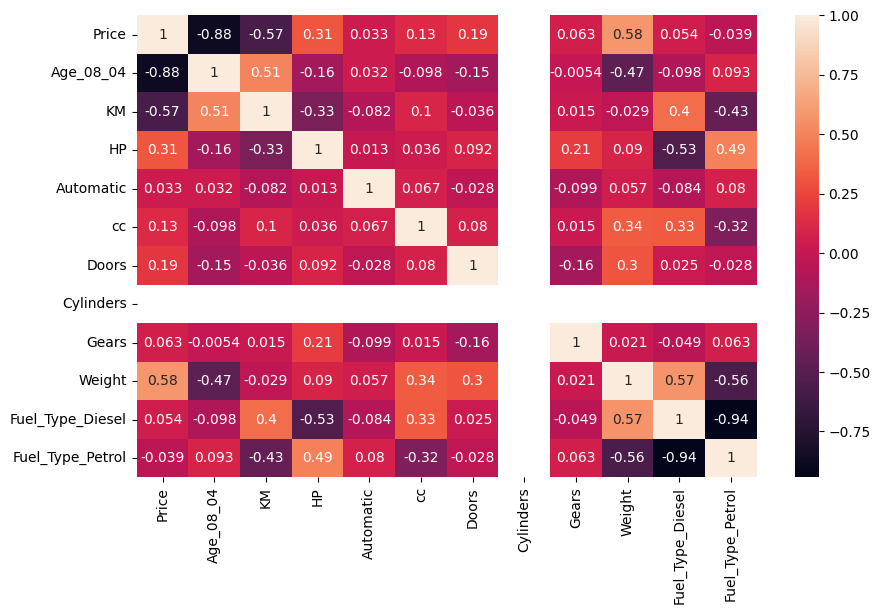

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True
)

plt.show()

In [32]:
X.dtypes

Age_08_04           int64
KM                  int64
HP                  int64
Automatic           int64
cc                  int64
Doors               int64
Cylinders           int64
Gears               int64
Weight              int64
Fuel_Type_Diesel     bool
Fuel_Type_Petrol     bool
dtype: object

In [33]:
# Convert features into numeric format

X_vif = X.apply(
    pd.to_numeric,
    errors="coerce"
)

In [34]:
# Fill missing values using median

X_vif = X_vif.fillna(
    X_vif.median()
)

In [38]:
import numpy as np

np.isfinite([1,2,3])

array([ True,  True,  True])

In [40]:
# Check missing values
X.isnull().sum()

Age_08_04           0
KM                  0
HP                  0
Automatic           0
cc                  0
Doors               0
Cylinders           0
Gears               0
Weight              0
Fuel_Type_Diesel    0
Fuel_Type_Petrol    0
dtype: int64

In [41]:
# Convert all columns to numeric

X_vif = X.apply(
    pd.to_numeric,
    errors="coerce"
)


# Replace missing values

X_vif = X_vif.fillna(
    X_vif.median()
)


# Check datatype

X_vif.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age_08_04         1436 non-null   int64
 1   KM                1436 non-null   int64
 2   HP                1436 non-null   int64
 3   Automatic         1436 non-null   int64
 4   cc                1436 non-null   int64
 5   Doors             1436 non-null   int64
 6   Cylinders         1436 non-null   int64
 7   Gears             1436 non-null   int64
 8   Weight            1436 non-null   int64
 9   Fuel_Type_Diesel  1436 non-null   bool 
 10  Fuel_Type_Petrol  1436 non-null   bool 
dtypes: bool(2), int64(9)
memory usage: 103.9 KB


In [1]:
print("Normalization and Standardization")
print("-"*50)

print("""
Normalization:
---------------
Normalization is a scaling technique that transforms data into a fixed range,
usually between 0 and 1.

Formula:
(X - Xmin) / (Xmax - Xmin)

Advantages:
1. Scales all features to the same range.
2. Improves the performance of distance-based algorithms.
3. Helps algorithms converge faster.

Example:
Original values: 10, 20, 30, 40
Normalized values: 0.0, 0.33, 0.67, 1.0


Standardization:
----------------
Standardization transforms data so that it has
Mean = 0
Standard Deviation = 1

Formula:
(X - Mean) / Standard Deviation

Advantages:
1. Handles different scales of variables.
2. Less affected by outliers than normalization.
3. Commonly used in Linear Regression, Logistic Regression, and SVM.

Why are they helpful?
---------------------
• Prevents variables with large values from dominating the model.
• Improves model accuracy.
• Speeds up model training.
• Makes coefficients easier to compare.
""")

Normalization and Standardization
--------------------------------------------------

Normalization:
---------------
Normalization is a scaling technique that transforms data into a fixed range,
usually between 0 and 1.

Formula:
(X - Xmin) / (Xmax - Xmin)

Advantages:
1. Scales all features to the same range.
2. Improves the performance of distance-based algorithms.
3. Helps algorithms converge faster.

Example:
Original values: 10, 20, 30, 40
Normalized values: 0.0, 0.33, 0.67, 1.0


Standardization:
----------------
Standardization transforms data so that it has
Mean = 0
Standard Deviation = 1

Formula:
(X - Mean) / Standard Deviation

Advantages:
1. Handles different scales of variables.
2. Less affected by outliers than normalization.
3. Commonly used in Linear Regression, Logistic Regression, and SVM.

Why are they helpful?
---------------------
• Prevents variables with large values from dominating the model.
• Improves model accuracy.
• Speeds up model training.
• Makes coeffic